In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from src.embedder import (
    stratified_sample, chunk_dataframe, load_embedding_model,
    embed_chunks, build_chroma_store, CHUNK_SIZE, CHUNK_OVERLAP
)

sns.set_theme(style='whitegrid')
%matplotlib inline

d:\pro_lang\Python\AI_Training\AI_Training_Projects\challenge_week7\rag-complaint-chatbot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../data/processed/filtered_complaints.csv')
print(f'Loaded {len(df):,} records')
df.head()
# print(df['product'].value_counts())

Loaded 445,456 records


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,...,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,narrative,clean_narrative,word_count
0,2025-06-13,Credit Card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,A XXXX XXXX card was opened under my name by a...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78230,...,Consent provided,Web,2025-06-13,Closed with non-monetary relief,Yes,NaN,14069121,A XXXX XXXX card was opened under my name by a...,a card was opened under my name by a fraudster...,82
1,2025-06-13,Savings Account,Checking account,Managing an account,Deposits and withdrawals,I made the mistake of using my wellsfargo debi...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,ID,83815,...,Consent provided,Web,2025-06-13,Closed with explanation,Yes,NaN,14061897,I made the mistake of using my wellsfargo debi...,i made the mistake of using my wellsfargo debi...,105
2,2025-06-12,Credit Card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,"Dear CFPB, I have a secured credit card with c...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",NY,11220,...,Consent provided,Web,2025-06-13,Closed with monetary relief,Yes,NaN,14047085,"Dear CFPB, I have a secured credit card with c...","dear cfpb, i have a secured credit card with c...",156
3,2025-06-12,Credit Card,General-purpose credit card or charge card,Incorrect information on your report,Account information incorrect,I have a Citi rewards cards. The credit balanc...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",IL,60067,...,Consent provided,Web,2025-06-12,Closed with explanation,Yes,NaN,14040217,I have a Citi rewards cards. The credit balanc...,i have a citi rewards cards. the credit balanc...,229
4,2025-06-09,Credit Card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,b'I am writing to dispute the following charge...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78413,...,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13968411,b'I am writing to dispute the following charge...,b'i am writing to dispute the following charge...,469


Sample size: 12,000

Category distribution in sample:
Product
Credit Card        5099
Savings Account    3779
Money Transfer     2658
Personal Loan       464
Name: count, dtype: int64


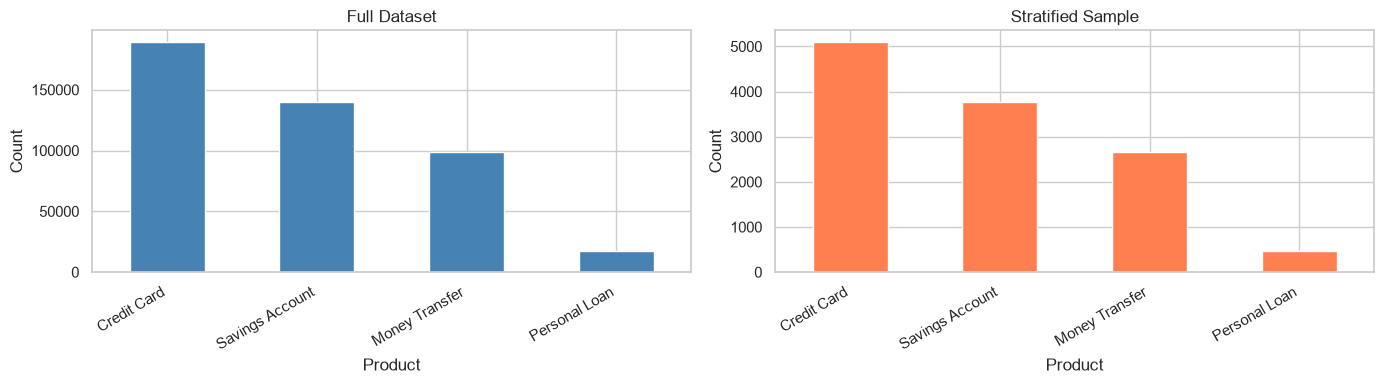

In [3]:
SAMPLE_SIZE = 12000
df_sample = stratified_sample(df, n=SAMPLE_SIZE)
print(f'Sample size: {len(df_sample):,}')
print('\nCategory distribution in sample:')
print(df_sample['Product'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Product'].value_counts().plot(kind='bar', ax=axes[0], title='Full Dataset', color='steelblue')
df_sample['Product'].value_counts().plot(kind='bar', ax=axes[1], title='Stratified Sample', color='coral')
for ax in axes:
    ax.set_xlabel('Product')
    ax.set_ylabel('Count')
    plt.sca(ax)
    plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/sample_distribution.png', dpi=120)
plt.show()

In [4]:
# chunk narratives
print(f'Chunk size: {CHUNK_SIZE} chars | Overlap: {CHUNK_OVERLAP} chars')

chunks = chunk_dataframe(df_sample, text_col='clean_narrative')
print(f'Total chunks: {len(chunks):,}')
print(f'Avg chunks per complaint: {len(chunks)/len(df_sample):.1f}')

# Chunk length distribution
chunk_lengths = [len(c['text']) for c in chunks]
pd.Series(chunk_lengths).describe()

Chunk size: 500 chars | Overlap: 50 chars
Total chunks: 34,079
Avg chunks per complaint: 2.8


count    34079.000000
mean       414.135538
std        133.947308
min         23.000000
25%        345.000000
50%        495.000000
75%        498.000000
max        500.000000
dtype: float64

In [5]:
# Show a sample chunk with metadata
sample_chunk = chunks[42]
print('Text:')
print(sample_chunk['text'])
print('\nMetadata:')
print(sample_chunk['metadata'])

Text:
following are all the details, day by day. , i applied for an amazon credit card , i received the letter from chase with the phone number to call after lifting my , 2022 : i lift the freeze on . -monday 2022, about pacific time, i called the phone number on the letter from chase. the chase employee checked my credit and my application was accepted. ( unfortunately, i shredded the letter from chase since my application was accepted ) -monday 2022, in the afternoon, i freeze the credit report on

Metadata:
{'Date received': '2022-08-29', 'Product': 'Credit Card', 'Sub-product': 'General-purpose credit card or charge card', 'Issue': 'Getting a credit card', 'Sub-issue': 'Delay in processing application', 'Consumer complaint narrative': 'My complaint is about four fraudulent activities which have occurred the day after my application for an Amazon/Chase Credit Card XXXX \n\nOn XX/XX/2022, I applied for an Amazon Credit card and I lift the freeze on my credit report on XXXX on XX/XX/2

In [6]:
# embed chunks
print('Loading embedding model: all-MiniLM-L6-v2 ...')
model = load_embedding_model()
print('Model loaded.') 

print(f'Embedding {len(chunks):,} chunks ...')
embeddings = embed_chunks(chunks, model, batch_size=128)
print(f'Embedding matrix shape: {embeddings.shape}')

Loading embedding model: all-MiniLM-L6-v2 ...


d:\pro_lang\Python\AI_Training\AI_Training_Projects\challenge_week7\rag-complaint-chatbot\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\A\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/

Model loaded.
Embedding 34,079 chunks ...


Batches: 100%|██████████| 267/267 [28:44<00:00,  6.46s/it]


Embedding matrix shape: (34079, 384)


In [7]:
# build and persist ChromaDB store
collection = build_chroma_store(
    chunks=chunks,
    embeddings=embeddings,
    persist_dir='../vector_store/chroma',
)
print(f'Collection count: {collection.count():,} chunks stored')

Collection count: 34,079 chunks stored


In [8]:
# smoke test - semantic search
from src.embedder import query_store

test_question = 'Why are customers complaining about credit card billing?'
hits = query_store(collection, test_question, model, k=3)

for i, hit in enumerate(hits, 1):
    print(f'--- Hit {i} (distance={hit["distance"]:.4f}) ---')
    print(f'Product: {hit["metadata"].get("product_category")}')
    print(hit['text'][:300])
    print()

--- Hit 1 (distance=0.2490) ---
Product: None
complaining about, billing issues represented the largest percentage of complaints ( 18 ), followed by gripes about interest rates ( 10 ), identity theft ( 7 ), credit reporting ( 7 ), or closing and canceling accounts ( 6 ). in the end, the majority ( 60 ) of all credit card complaints are resolved

--- Hit 2 (distance=0.3269) ---
Product: None
and that they will document the complaint with no further follow-up.in summary, i pay more than in credit card fees a year for a very bad customer service for a luxury financial product.

--- Hit 3 (distance=0.3693) ---
Product: None
see, for example, v. , 141 cal. app. 3d 108, 190 cal. rptr. 122 ( 1st dist. 1983 ) a card issuer is not liable for a billing error by a retailer. civ. code, 1747.65, subd. ( a ) 55:27. duty to respond to cardholder inquiry if a card issuer fails to give a timely response to an inquiry of a cardholde

